In [1]:
import os
import pandas as pd
from PIL import Image
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import time


base_dir = "./faces-png"
data = []

for userid in sorted(os.listdir(base_dir)):
    user_dir = os.path.join(base_dir, userid)
    if not os.path.isdir(user_dir):
        continue

    for file in sorted(os.listdir(user_dir)):
        if file.endswith(".png"):
            filename = file[:-4]
            parts = filename.split("_")

            if len(parts) == 4:
                file_userid, pose, expression, eyes = parts
                scale = 1
            elif len(parts) == 5:
                file_userid, pose, expression, eyes, scale_str = parts
                try:
                    scale = int(scale_str)
                except ValueError:
                    print(f"[SKIP] Skala tidak valid: {file}")
                    continue
            else:
                print(f"[SKIP] Format nama file salah: {file}")
                continue

            filepath = os.path.join(user_dir, file)
            data.append({
                "userid": file_userid,
                "pose": pose,
                "expression": expression,
                "eyes": eyes,
                "scale": scale,
                "path": filepath
            })

df = pd.DataFrame(data)

print(f"Jumlah gambar dimuat: {len(df)}")
display(df.head())


Jumlah gambar dimuat: 1776


,userid,pose,expression,eyes,scale,path
0,at33,left,angry,open,1,./faces-png\at33\at33_left_angry_open.png
1,at33,left,angry,open,2,./faces-png\at33\at33_left_angry_open_2.png
2,at33,left,angry,open,4,./faces-png\at33\at33_left_angry_open_4.png
3,at33,left,angry,sunglasses,1,./faces-png\at33\at33_left_angry_sunglasses.png
4,at33,left,angry,sunglasses,2,./faces-png\at33\at33_left_angry_sunglasses_2.png


# EDA

In [2]:
print("Jumlah total gambar:", len(df))

Jumlah total gambar: 1776


In [3]:
print(df['eyes'].value_counts())

eyes
open          891
sunglasses    885
Name: count, dtype: int64


In [4]:
print(df['scale'].value_counts())

scale
1    592
2    592
4    592
Name: count, dtype: int64


In [5]:
print(df.isnull().sum())

userid        0
pose          0
expression    0
eyes          0
scale         0
path          0
dtype: int64


# Preprocessing

In [6]:
df = df.drop('userid', axis=1)

In [7]:
def load_and_preprocess_image(path, size=(64, 60)):
    img = Image.open(path).convert('L')
    img = img.resize(size)
    img_array = np.array(img) / 255.0
    return img_array.flatten()

df['image_array'] = df['path'].apply(lambda p: load_and_preprocess_image(p))

In [8]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['eyes'])

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'open': 0, 'sunglasses': 1}


In [9]:
X = np.stack(df['image_array'].values)
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# SVM

In [10]:
start_time = time.time()

param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(SVC(), param_grid_svm, cv=5, verbose=1, n_jobs=-1)
grid_svm.fit(X_train, y_train)

y_pred_svm = grid_svm.predict(X_test)

print("Best parameters for SVM:", grid_svm.best_params_)
print("Accuracy SVM:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

print("Waktu eksekusi SVM: {:.2f} detik".format(time.time() - start_time))

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters for SVM: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Accuracy SVM: 0.9887429643527205
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       250
           1       1.00      0.98      0.99       283

    accuracy                           0.99       533
   macro avg       0.99      0.99      0.99       533
weighted avg       0.99      0.99      0.99       533

Waktu eksekusi SVM: 112.29 detik


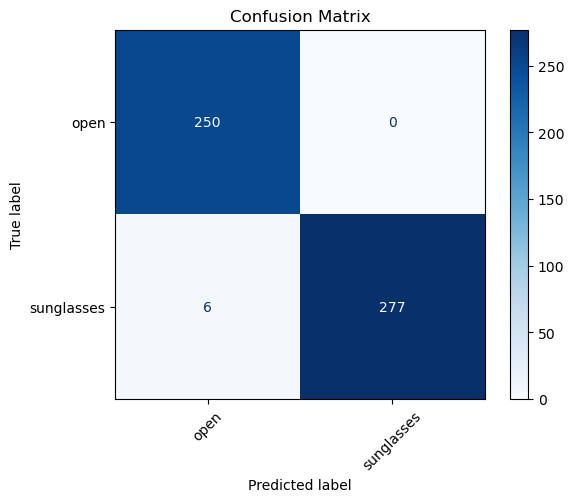

In [11]:
cm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

# Random Forest

In [12]:
start_time = time.time()

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, verbose=1, n_jobs=-1)
grid_rf.fit(X_train, y_train)

y_pred_rf = grid_rf.predict(X_test)

print("Best parameters for Random Forest:", grid_rf.best_params_)
print("Accuracy Random Forest:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

print("Waktu eksekusi RF: {:.2f} detik".format(time.time() - start_time))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters for Random Forest: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Accuracy Random Forest: 0.9831144465290806
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       250
           1       1.00      0.97      0.98       283

    accuracy                           0.98       533
   macro avg       0.98      0.98      0.98       533
weighted avg       0.98      0.98      0.98       533

Waktu eksekusi RF: 110.73 detik


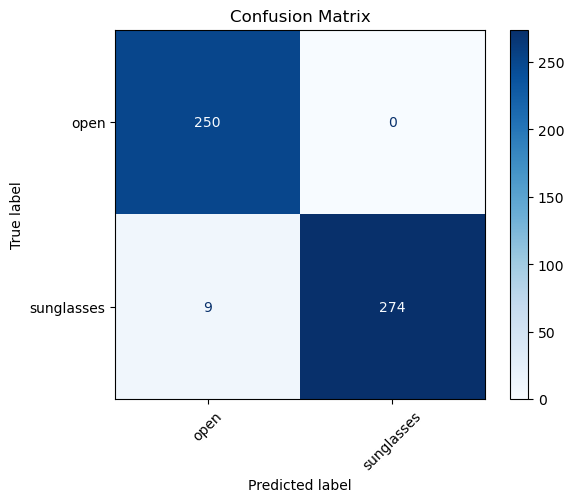

In [13]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

# KNN

In [14]:
start_time = time.time()

param_grid_knn = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, verbose=1, n_jobs=-1)
grid_knn.fit(X_train, y_train)

y_pred_knn = grid_knn.predict(X_test)

print("Best parameters for KNN:", grid_knn.best_params_)
print("Accuracy KNN:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
print("Waktu eksekusi KNN: {:.2f} detik".format(time.time() - start_time))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters for KNN: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
Accuracy KNN: 0.9737335834896811
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       250
           1       0.98      0.97      0.98       283

    accuracy                           0.97       533
   macro avg       0.97      0.97      0.97       533
weighted avg       0.97      0.97      0.97       533

Waktu eksekusi KNN: 16.61 detik


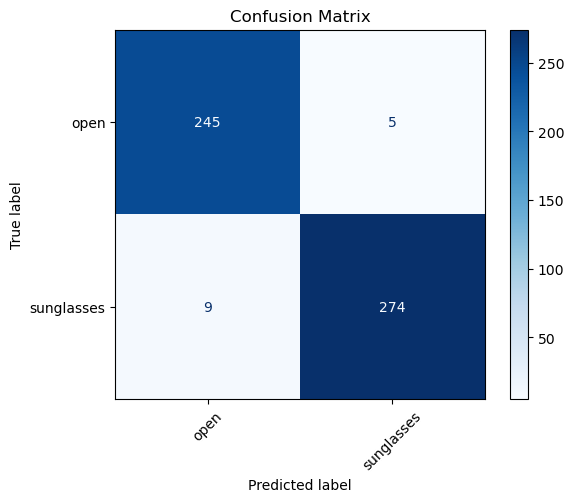

In [15]:
cm = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

# Kesimpulan

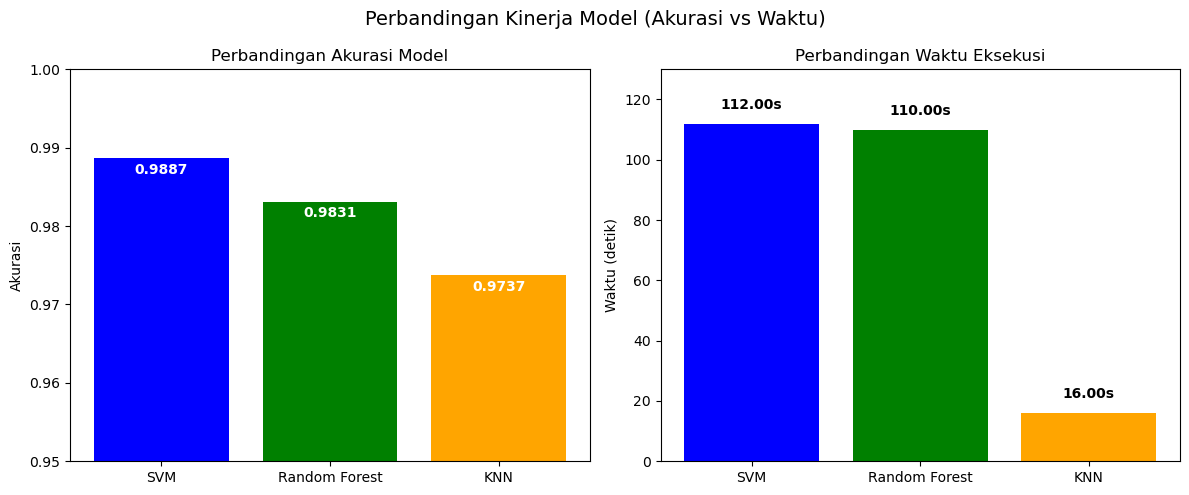

In [25]:
models = ['SVM', 'Random Forest', 'KNN']
accuracies = [0.9887, 0.9831, 0.9737]
times = [112, 110, 16]

fig, ax1 = plt.subplots(1, 2, figsize=(12, 5))

ax1[0].bar(models, accuracies, color=['blue', 'green', 'orange'])
ax1[0].set_title('Perbandingan Akurasi Model')
ax1[0].set_ylabel('Akurasi')
ax1[0].set_ylim([0.95, 1.00])
for i, v in enumerate(accuracies):
    ax1[0].text(i, v - 0.002, f"{v:.4f}", ha='center', color='white', fontweight='bold')

ax1[1].bar(models, times, color=['blue', 'green', 'orange'])
ax1[1].set_title('Perbandingan Waktu Eksekusi')
ax1[1].set_ylim([0, 130])
ax1[1].set_ylabel('Waktu (detik)')
for i, v in enumerate(times):
    ax1[1].text(i, v + 5, f"{v:.2f}s", ha='center', color='black', fontweight='bold')

plt.suptitle('Perbandingan Kinerja Model (Akurasi vs Waktu)', fontsize=14)
plt.tight_layout()
plt.show()




#  **1. Akurasi Model**

* **SVM** memiliki akurasi tertinggi: **0.9887**
* Disusul oleh **Random Forest**: **0.9831**
* **KNN** memiliki akurasi paling rendah: **0.9737**

> **Kesimpulan akurasi:**
> Semua model memberikan performa yang sangat baik (akurasi di atas 97%), namun **SVM unggul dalam hal ketepatan prediksi**.
---

###  **2. Waktu Eksekusi**

* **SVM** membutuhkan waktu eksekusi paling lama: **112 detik**
* **Random Forest** sedikit lebih cepat: **110 detik**
* **KNN** jauh lebih cepat: **hanya 16 detik**

> **Kesimpulan waktu eksekusi:**
> **KNN unggul secara signifikan dari segi kecepatan**, membuatnya sangat cocok untuk aplikasi yang memerlukan hil cepat.

---

###  **Trade-off: Akurasi vs Waktu**

| Model             | Akurasi | Waktu Eksekusi |
| ----------------- | ------- | -------------- |
| **SVM**           | 0.9887  | 112 detik      |
| **Random Forest** | 0.9831  | 110 detik      |
| **KNN**           | 0.9737  | 16 detik       |

* **SVM** dan **Random Forest** cocok untuk kasus di mana **akurasi lebih penting dari waktu**, misalnya dalam diagnosis medis.
* **KNN** bisa dipertimbangkan untuk **real-time atau aplikasi cepat**, meskipun dengan sediit pengorbanan akurasi.

---

###  **Rekomendasi (tergantung kebutuhan):**

* **Akurasi maksimal → SVM**
* **Kompromi akurasi & waktu → Random Forest**
* **Eksekusi cepat → KNN**

In [17]:
import joblib

joblib.dump(grid_svm, 'svm_model.pkl')

['svm_model.pkl']